# BMW Global Sales Analysis: Strategic Insights & Recommendations (2018-2025)

## Executive Summary

This comprehensive analysis examines BMW's global sales performance across multiple regions, models, and market segments from 2018 to 2025. The report provides data-driven insights into market dynamics, electrification progress, premium segment performance, and macroeconomic impacts, culminating in strategic recommendations for future growth.

### Key Focus Areas:
- Regional market performance and share analysis
- Model portfolio optimization opportunities
- Battery Electric Vehicle (BEV) adoption trends
- Premium segment penetration strategies
- Macroeconomic sensitivity and pricing elasticity
- Competitive positioning and market expansion


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
import warnings
warnings.filterwarnings('ignore')

# Set Professional Style (Matching Previous Project Aesthetics)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Custom Color Scheme - Professional Blue Tones
BMW_BLUE = '#1E3A8A'
BMW_DARK_BLUE = '#1E40AF'
BMW_LIGHT_BLUE = '#3B82F6'
ACCENT_GREEN = '#10B981'
ACCENT_ORANGE = '#F59E0B'
ACCENT_RED = '#EF4444'
NEUTRAL_GRAY = '#6B7280'
DARK_BG = '#1F2937'
TEXT_WHITE = '#F9FAFB'

# Font Settings
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
LARGE_SIZE = 18

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=LARGE_SIZE)

# Load Dataset
df = pd.read_csv('bmw_global_sales_2018_2025.csv')

# Data Preprocessing
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Revenue_Millions'] = df['Revenue_EUR'] / 1e6

print(f"Dataset Shape: {df.shape}")
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nRegions Covered: {df['Region'].unique()}")
print(f"\nModels Analyzed: {df['Model'].nunique()}")
print(f"\nTotal Records: {len(df):,}")
print(f"\nData Types Summary:")
print(df.dtypes)

Dataset Shape: (3072, 14)

Date Range: 2018-01-01 00:00:00 to 2025-12-01 00:00:00

Regions Covered: ['Europe' 'China' 'USA' 'RestOfWorld']

Models Analyzed: 8

Total Records: 3,072

Data Types Summary:
Year                         int64
Month                        int64
Region                      object
Model                       object
Units_Sold                   int64
Avg_Price_EUR                int64
Revenue_EUR                  int64
BEV_Share                  float64
Premium_Share              float64
GDP_Growth                 float64
Fuel_Price_Index           float64
Date                datetime64[ns]
Year_Month               period[M]
Revenue_Millions           float64
dtype: object


## 1. Global Market Performance Overview

Analyzing overall sales trends, revenue generation, and market evolution across the observation period.

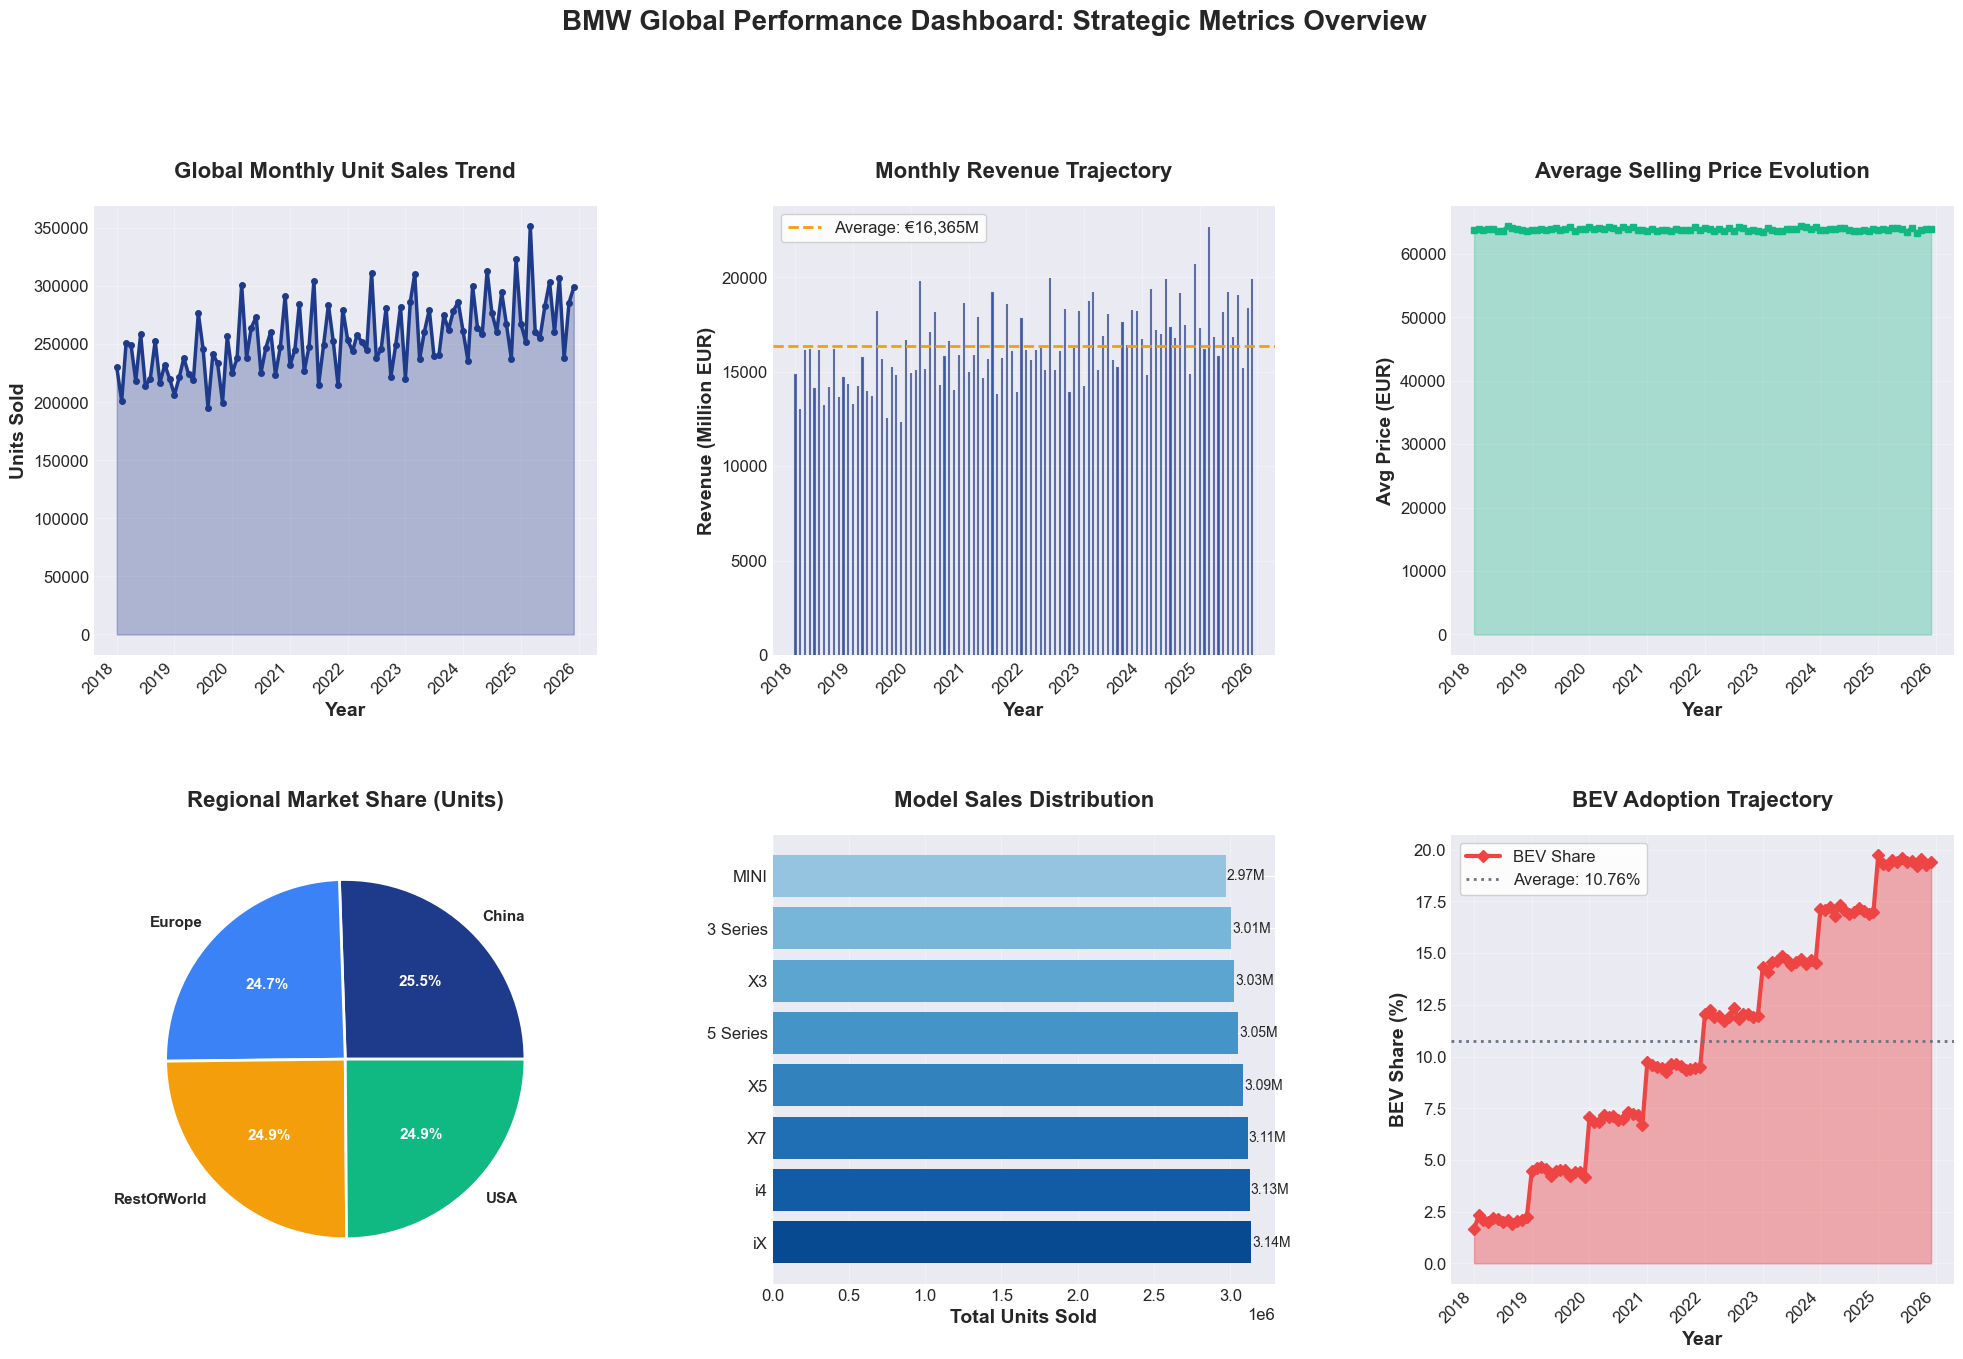


KEY PERFORMANCE INDICATORS SUMMARY
Total Units Sold (2018-2025): 24,515,445
Total Revenue Generated: €1571.02 Billion
Average Monthly Revenue: €16,364.8 Million
Average Selling Price: €63,855
Peak Monthly Sales: 351,705 units
Current BEV Share: 19.40%
BEV Growth Rate: 1077.8%


In [2]:
# 1.1 High-Level KPI Dashboard
fig = plt.figure(figsize=(24, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# KPI 1: Total Units Sold Trend
ax0 = plt.subplot(gs[0, 0])
monthly_units = df.groupby('Date')['Units_Sold'].sum().reset_index()
ax0.fill_between(monthly_units['Date'], monthly_units['Units_Sold'], 
                 alpha=0.3, color=BMW_BLUE)
ax0.plot(monthly_units['Date'], monthly_units['Units_Sold'], 
        color=BMW_BLUE, linewidth=2.5, marker='o', markersize=4)
ax0.set_title("Global Monthly Unit Sales Trend", pad=20, weight='bold')
ax0.set_xlabel("Year", weight='bold')
ax0.set_ylabel("Units Sold", weight='bold')
ax0.grid(True, alpha=0.3)
plt.setp(ax0.xaxis.get_majorticklabels(), rotation=45, ha='right')

# KPI 2: Revenue Evolution
ax1 = plt.subplot(gs[0, 1])
monthly_revenue = df.groupby('Date')['Revenue_Millions'].sum().reset_index()
ax1.bar(monthly_revenue['Date'], monthly_revenue['Revenue_Millions'],
       color=BMW_LIGHT_BLUE, alpha=0.7, edgecolor=BMW_BLUE, linewidth=1.5)
ax1.axhline(monthly_revenue['Revenue_Millions'].mean(), 
           color=ACCENT_ORANGE, linestyle='--', linewidth=2, 
           label=f"Average: €{monthly_revenue['Revenue_Millions'].mean():,.0f}M")
ax1.set_title("Monthly Revenue Trajectory", pad=20, weight='bold')
ax1.set_xlabel("Year", weight='bold')
ax1.set_ylabel("Revenue (Million EUR)", weight='bold')
ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# KPI 3: Average Price Trend
ax2 = plt.subplot(gs[0, 2])
monthly_price = df.groupby('Date')['Avg_Price_EUR'].mean().reset_index()
ax2.plot(monthly_price['Date'], monthly_price['Avg_Price_EUR'],
        color=ACCENT_GREEN, linewidth=2.5, marker='s', markersize=5)
ax2.fill_between(monthly_price['Date'], monthly_price['Avg_Price_EUR'],
                alpha=0.3, color=ACCENT_GREEN)
ax2.set_title("Average Selling Price Evolution", pad=20, weight='bold')
ax2.set_xlabel("Year", weight='bold')
ax2.set_ylabel("Avg Price (EUR)", weight='bold')
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# KPI 4: Regional Market Share (Treemap-style)
ax3 = plt.subplot(gs[1, 0])
region_summary = df.groupby('Region').agg({
    'Units_Sold': 'sum',
    'Revenue_Millions': 'sum'
}).reset_index()
region_summary['Share'] = region_summary['Units_Sold'] / region_summary['Units_Sold'].sum() * 100
colors_region = [BMW_BLUE, BMW_LIGHT_BLUE, ACCENT_ORANGE, ACCENT_GREEN]
wedges, texts, autotexts = ax3.pie(region_summary['Units_Sold'], 
                                   labels=region_summary['Region'],
                                   autopct='%1.1f%%', 
                                   colors=colors_region,
                                   textprops={'fontsize': 11, 'weight': 'bold'},
                                   wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.setp(autotexts, size=11, weight="bold", color="white")
ax3.set_title("Regional Market Share (Units)", pad=20, weight='bold')

# KPI 5: Model Portfolio Distribution
ax4 = plt.subplot(gs[1, 1])
model_summary = df.groupby('Model')['Units_Sold'].sum().sort_values(ascending=True)
bars = ax4.barh(model_summary.index, model_summary.values, 
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(model_summary))))
ax4.set_title("Model Sales Distribution", pad=20, weight='bold')
ax4.set_xlabel("Total Units Sold", weight='bold')
ax4.invert_yaxis()
for i, (model, value) in enumerate(zip(model_summary.index, model_summary.values)):
    ax4.text(value + 5000, i, f'{value/1e6:.2f}M', va='center', fontsize=10)
ax4.grid(True, alpha=0.3, axis='x')

# KPI 6: BEV Adoption Rate Over Time
ax5 = plt.subplot(gs[1, 2])
monthly_bev = df.groupby('Date')['BEV_Share'].mean().reset_index()
ax5.plot(monthly_bev['Date'], monthly_bev['BEV_Share'] * 100,
        color=ACCENT_RED, linewidth=3, marker='D', markersize=6,
        label='BEV Share')
ax5.fill_between(monthly_bev['Date'], monthly_bev['BEV_Share'] * 100,
                alpha=0.4, color=ACCENT_RED)
ax5.axhline(y=monthly_bev['BEV_Share'].mean() * 100, 
           color=NEUTRAL_GRAY, linestyle=':', linewidth=2,
           label=f"Average: {monthly_bev['BEV_Share'].mean()*100:.2f}%")
ax5.set_title("BEV Adoption Trajectory", pad=20, weight='bold')
ax5.set_xlabel("Year", weight='bold')
ax5.set_ylabel("BEV Share (%)", weight='bold')
ax5.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax5.grid(True, alpha=0.3)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle("BMW Global Performance Dashboard: Strategic Metrics Overview", 
            fontsize=20, weight='bold', y=1.02)
plt.show()

# Display Key Statistics
print("\n" + "="*80)
print("KEY PERFORMANCE INDICATORS SUMMARY")
print("="*80)
print(f"Total Units Sold (2018-2025): {df['Units_Sold'].sum():,.0f}")
print(f"Total Revenue Generated: €{df['Revenue_EUR'].sum()/1e9:.2f} Billion")
print(f"Average Monthly Revenue: €{monthly_revenue['Revenue_Millions'].mean():,.1f} Million")
print(f"Average Selling Price: €{df['Avg_Price_EUR'].mean():,.0f}")
print(f"Peak Monthly Sales: {monthly_units['Units_Sold'].max():,.0f} units")
print(f"Current BEV Share: {monthly_bev['BEV_Share'].iloc[-1]*100:.2f}%")
print(f"BEV Growth Rate: {((monthly_bev['BEV_Share'].iloc[-1] / monthly_bev['BEV_Share'].iloc[0]) - 1) * 100:.1f}%")
print("="*80)

## 2. Regional Market Dynamics & Competitive Landscape

Deep-dive analysis into regional performance, market characteristics, and strategic positioning.

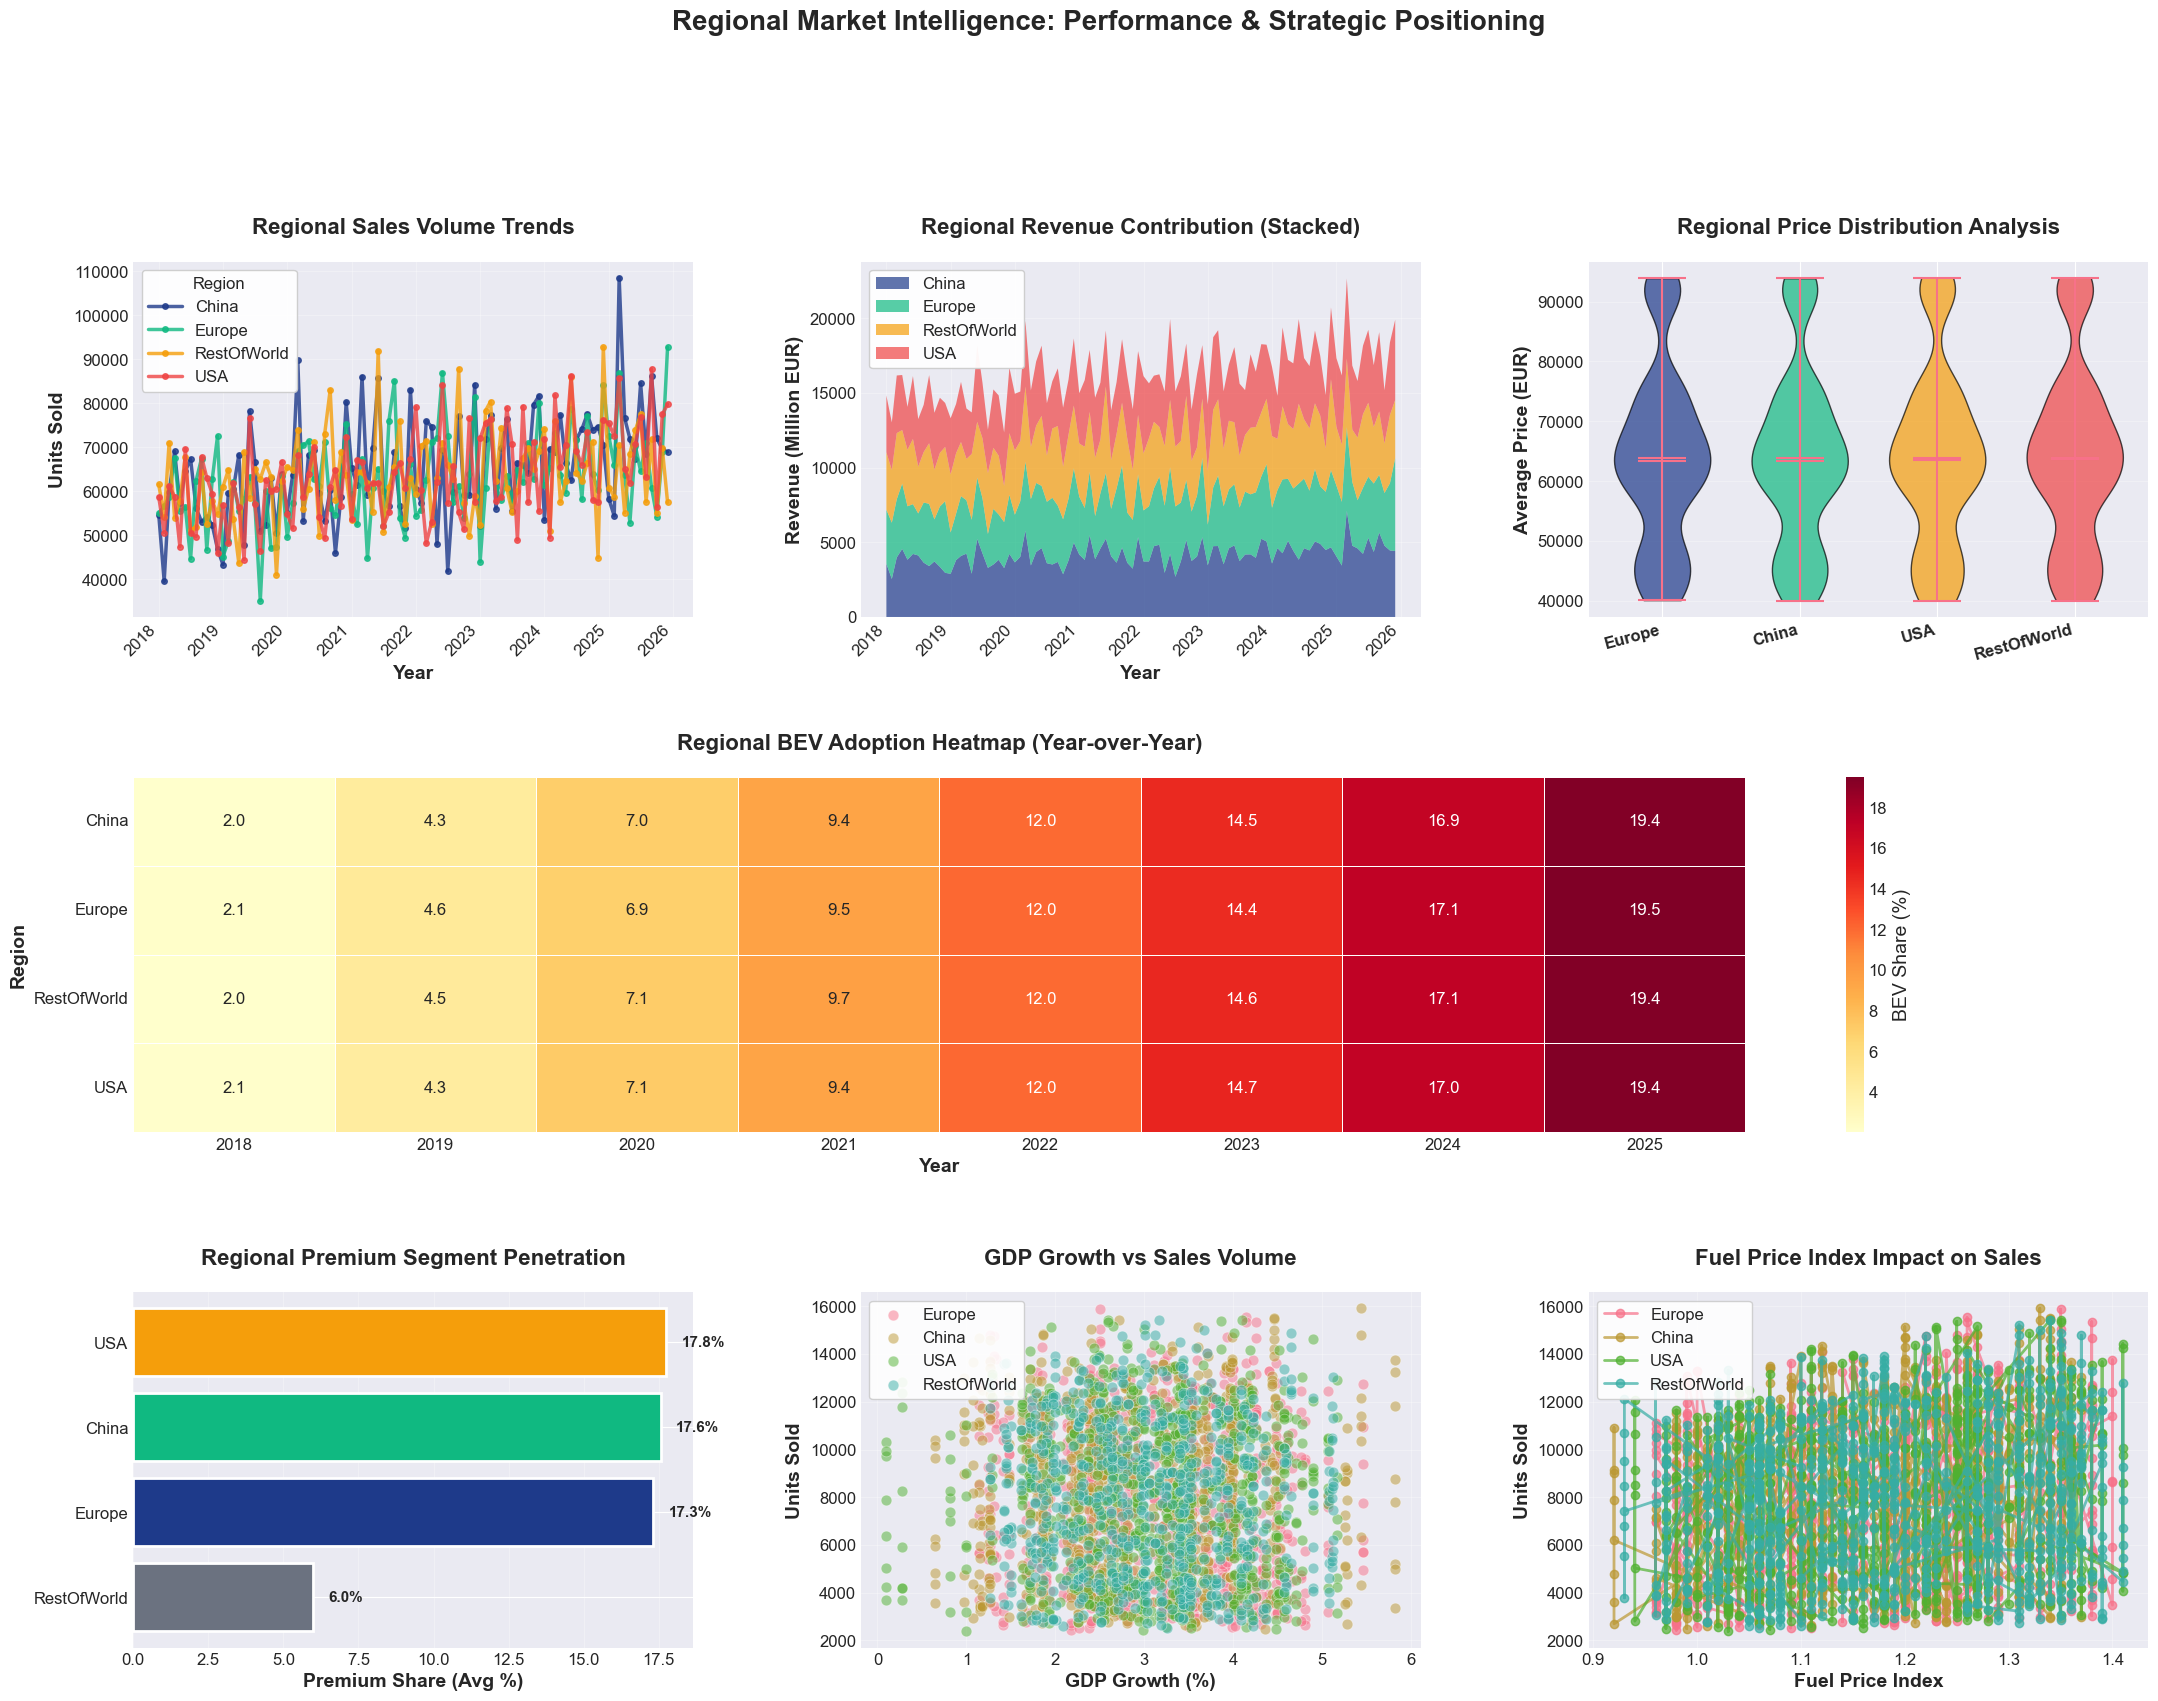


REGIONAL MARKET INSIGHTS

EUROPE:
  Total Units: 6,045,176
  Revenue Contribution: €388,879M
  Avg Price: €63,809
  BEV Share: 10.77%
  Premium Share: 17.3%

CHINA:
  Total Units: 6,256,750
  Revenue Contribution: €401,755M
  Avg Price: €63,847
  BEV Share: 10.71%
  Premium Share: 17.6%

USA:
  Total Units: 6,099,647
  Revenue Contribution: €389,314M
  Avg Price: €63,883
  BEV Share: 10.76%
  Premium Share: 17.8%

RESTOFWORLD:
  Total Units: 6,113,872
  Revenue Contribution: €391,071M
  Avg Price: €63,879
  BEV Share: 10.79%
  Premium Share: 6.0%



In [3]:
# 2.1 Regional Performance Matrix
fig = plt.figure(figsize=(26, 18))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.3)

# 2.1.1 Regional Sales Trends (Multi-line)
ax0 = plt.subplot(gs[0, 0])
region_trend = df.groupby(['Date', 'Region'])['Units_Sold'].sum().unstack()
colors = [BMW_BLUE, ACCENT_GREEN, ACCENT_ORANGE, ACCENT_RED]
for i, region in enumerate(region_trend.columns):
    ax0.plot(region_trend.index, region_trend[region], 
            label=region, color=colors[i % len(colors)], 
            linewidth=2.5, marker='o', markersize=4, alpha=0.8)
ax0.set_title("Regional Sales Volume Trends", pad=20, weight='bold')
ax0.set_xlabel("Year", weight='bold')
ax0.set_ylabel("Units Sold", weight='bold')
ax0.legend(title='Region', loc='upper left', frameon=True, 
          facecolor='white', framealpha=0.95)
ax0.grid(True, alpha=0.3)
plt.setp(ax0.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2.1.2 Regional Revenue Contribution (Stacked Area)
ax1 = plt.subplot(gs[0, 1])
region_revenue = df.groupby(['Date', 'Region'])['Revenue_Millions'].sum().unstack()
ax1.stackplot(region_revenue.index, *[region_revenue[col] for col in region_revenue.columns],
             labels=region_revenue.columns, colors=colors, alpha=0.7)
ax1.set_title("Regional Revenue Contribution (Stacked)", pad=20, weight='bold')
ax1.set_xlabel("Year", weight='bold')
ax1.set_ylabel("Revenue (Million EUR)", weight='bold')
ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95)
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2.1.3 Regional Average Price Comparison (Box-Violin Hybrid)
ax2 = plt.subplot(gs[0, 2])
price_data = [df[df['Region'] == r]['Avg_Price_EUR'].values for r in df['Region'].unique()]
bp = ax2.violinplot(price_data, positions=range(len(df['Region'].unique())), 
                   widths=0.7, showmeans=True, showmedians=True)
for pc, color in zip(bp['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)
ax2.set_xticks(range(len(df['Region'].unique())))
ax2.set_xticklabels(df['Region'].unique(), rotation=15, ha='right', weight='bold')
ax2.set_title("Regional Price Distribution Analysis", pad=20, weight='bold')
ax2.set_ylabel("Average Price (EUR)", weight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 2.1.4 Regional BEV Adoption Heatmap
ax3 = plt.subplot(gs[1, :])
bev_pivot = df.pivot_table(index='Region', columns='Year', 
                          values='BEV_Share', aggfunc='mean')
sns.heatmap(bev_pivot * 100, annot=True, fmt='.1f', cmap='YlOrRd', 
           ax=ax3, cbar_kws={'label': 'BEV Share (%)'}, 
           linewidths=0.5, linecolor='white')
ax3.set_title("Regional BEV Adoption Heatmap (Year-over-Year)", pad=20, weight='bold', fontsize=16)
ax3.set_xlabel("Year", weight='bold', fontsize=14)
ax3.set_ylabel("Region", weight='bold', fontsize=14)
plt.setp(ax3.get_xticklabels(), rotation=0, ha='center')
plt.setp(ax3.get_yticklabels(), rotation=0)

# 2.1.5 Regional Premium Segment Penetration
ax4 = plt.subplot(gs[2, 0])
region_premium = df.groupby('Region')['Premium_Share'].mean().sort_values(ascending=True)
bars = ax4.barh(region_premium.index, region_premium.values,
               color=[BMW_BLUE if r == 'Europe' else ACCENT_GREEN if r == 'China' 
                     else ACCENT_ORANGE if r == 'USA' else NEUTRAL_GRAY 
                     for r in region_premium.index],
               edgecolor='white', linewidth=2)
ax4.set_title("Regional Premium Segment Penetration", pad=20, weight='bold')
ax4.set_xlabel("Premium Share (Avg %)", weight='bold')
for i, v in enumerate(region_premium.values):
    ax4.text(v + 0.5, i, f'{v:.1f}%', va='center', weight='bold', fontsize=11)
ax4.grid(True, alpha=0.3, axis='x')

# 2.1.6 Regional GDP Correlation Scatter
ax5 = plt.subplot(gs[2, 1])
for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    ax5.scatter(region_data['GDP_Growth'], region_data['Units_Sold'],
               alpha=0.5, s=60, label=region, edgecolors='white', linewidth=0.5)
ax5.set_title("GDP Growth vs Sales Volume", pad=20, weight='bold')
ax5.set_xlabel("GDP Growth (%)", weight='bold')
ax5.set_ylabel("Units Sold", weight='bold')
ax5.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax5.grid(True, alpha=0.3)

# 2.1.7 Regional Fuel Price Sensitivity
ax6 = plt.subplot(gs[2, 2])
for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    ax6.plot(region_data['Fuel_Price_Index'], region_data['Units_Sold'],
            marker='o', linestyle='-', label=region, alpha=0.7, linewidth=2)
ax6.set_title("Fuel Price Index Impact on Sales", pad=20, weight='bold')
ax6.set_xlabel("Fuel Price Index", weight='bold')
ax6.set_ylabel("Units Sold", weight='bold')
ax6.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax6.grid(True, alpha=0.3)

plt.suptitle("Regional Market Intelligence: Performance & Strategic Positioning", 
            fontsize=20, weight='bold', y=1.02)
plt.show()

# Regional Analysis Summary
print("\n" + "="*80)
print("REGIONAL MARKET INSIGHTS")
print("="*80)
for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    print(f"\n{region.upper()}:")
    print(f"  Total Units: {region_data['Units_Sold'].sum():,.0f}")
    print(f"  Revenue Contribution: €{region_data['Revenue_Millions'].sum():,.0f}M")
    print(f"  Avg Price: €{region_data['Avg_Price_EUR'].mean():,.0f}")
    print(f"  BEV Share: {region_data['BEV_Share'].mean()*100:.2f}%")
    print(f"  Premium Share: {region_data['Premium_Share'].mean():.1f}%")
print("\n" + "="*80)

## 3. Model Portfolio Performance & Strategic Analysis

Comprehensive evaluation of model-level performance, lifecycle trends, and portfolio optimization opportunities.

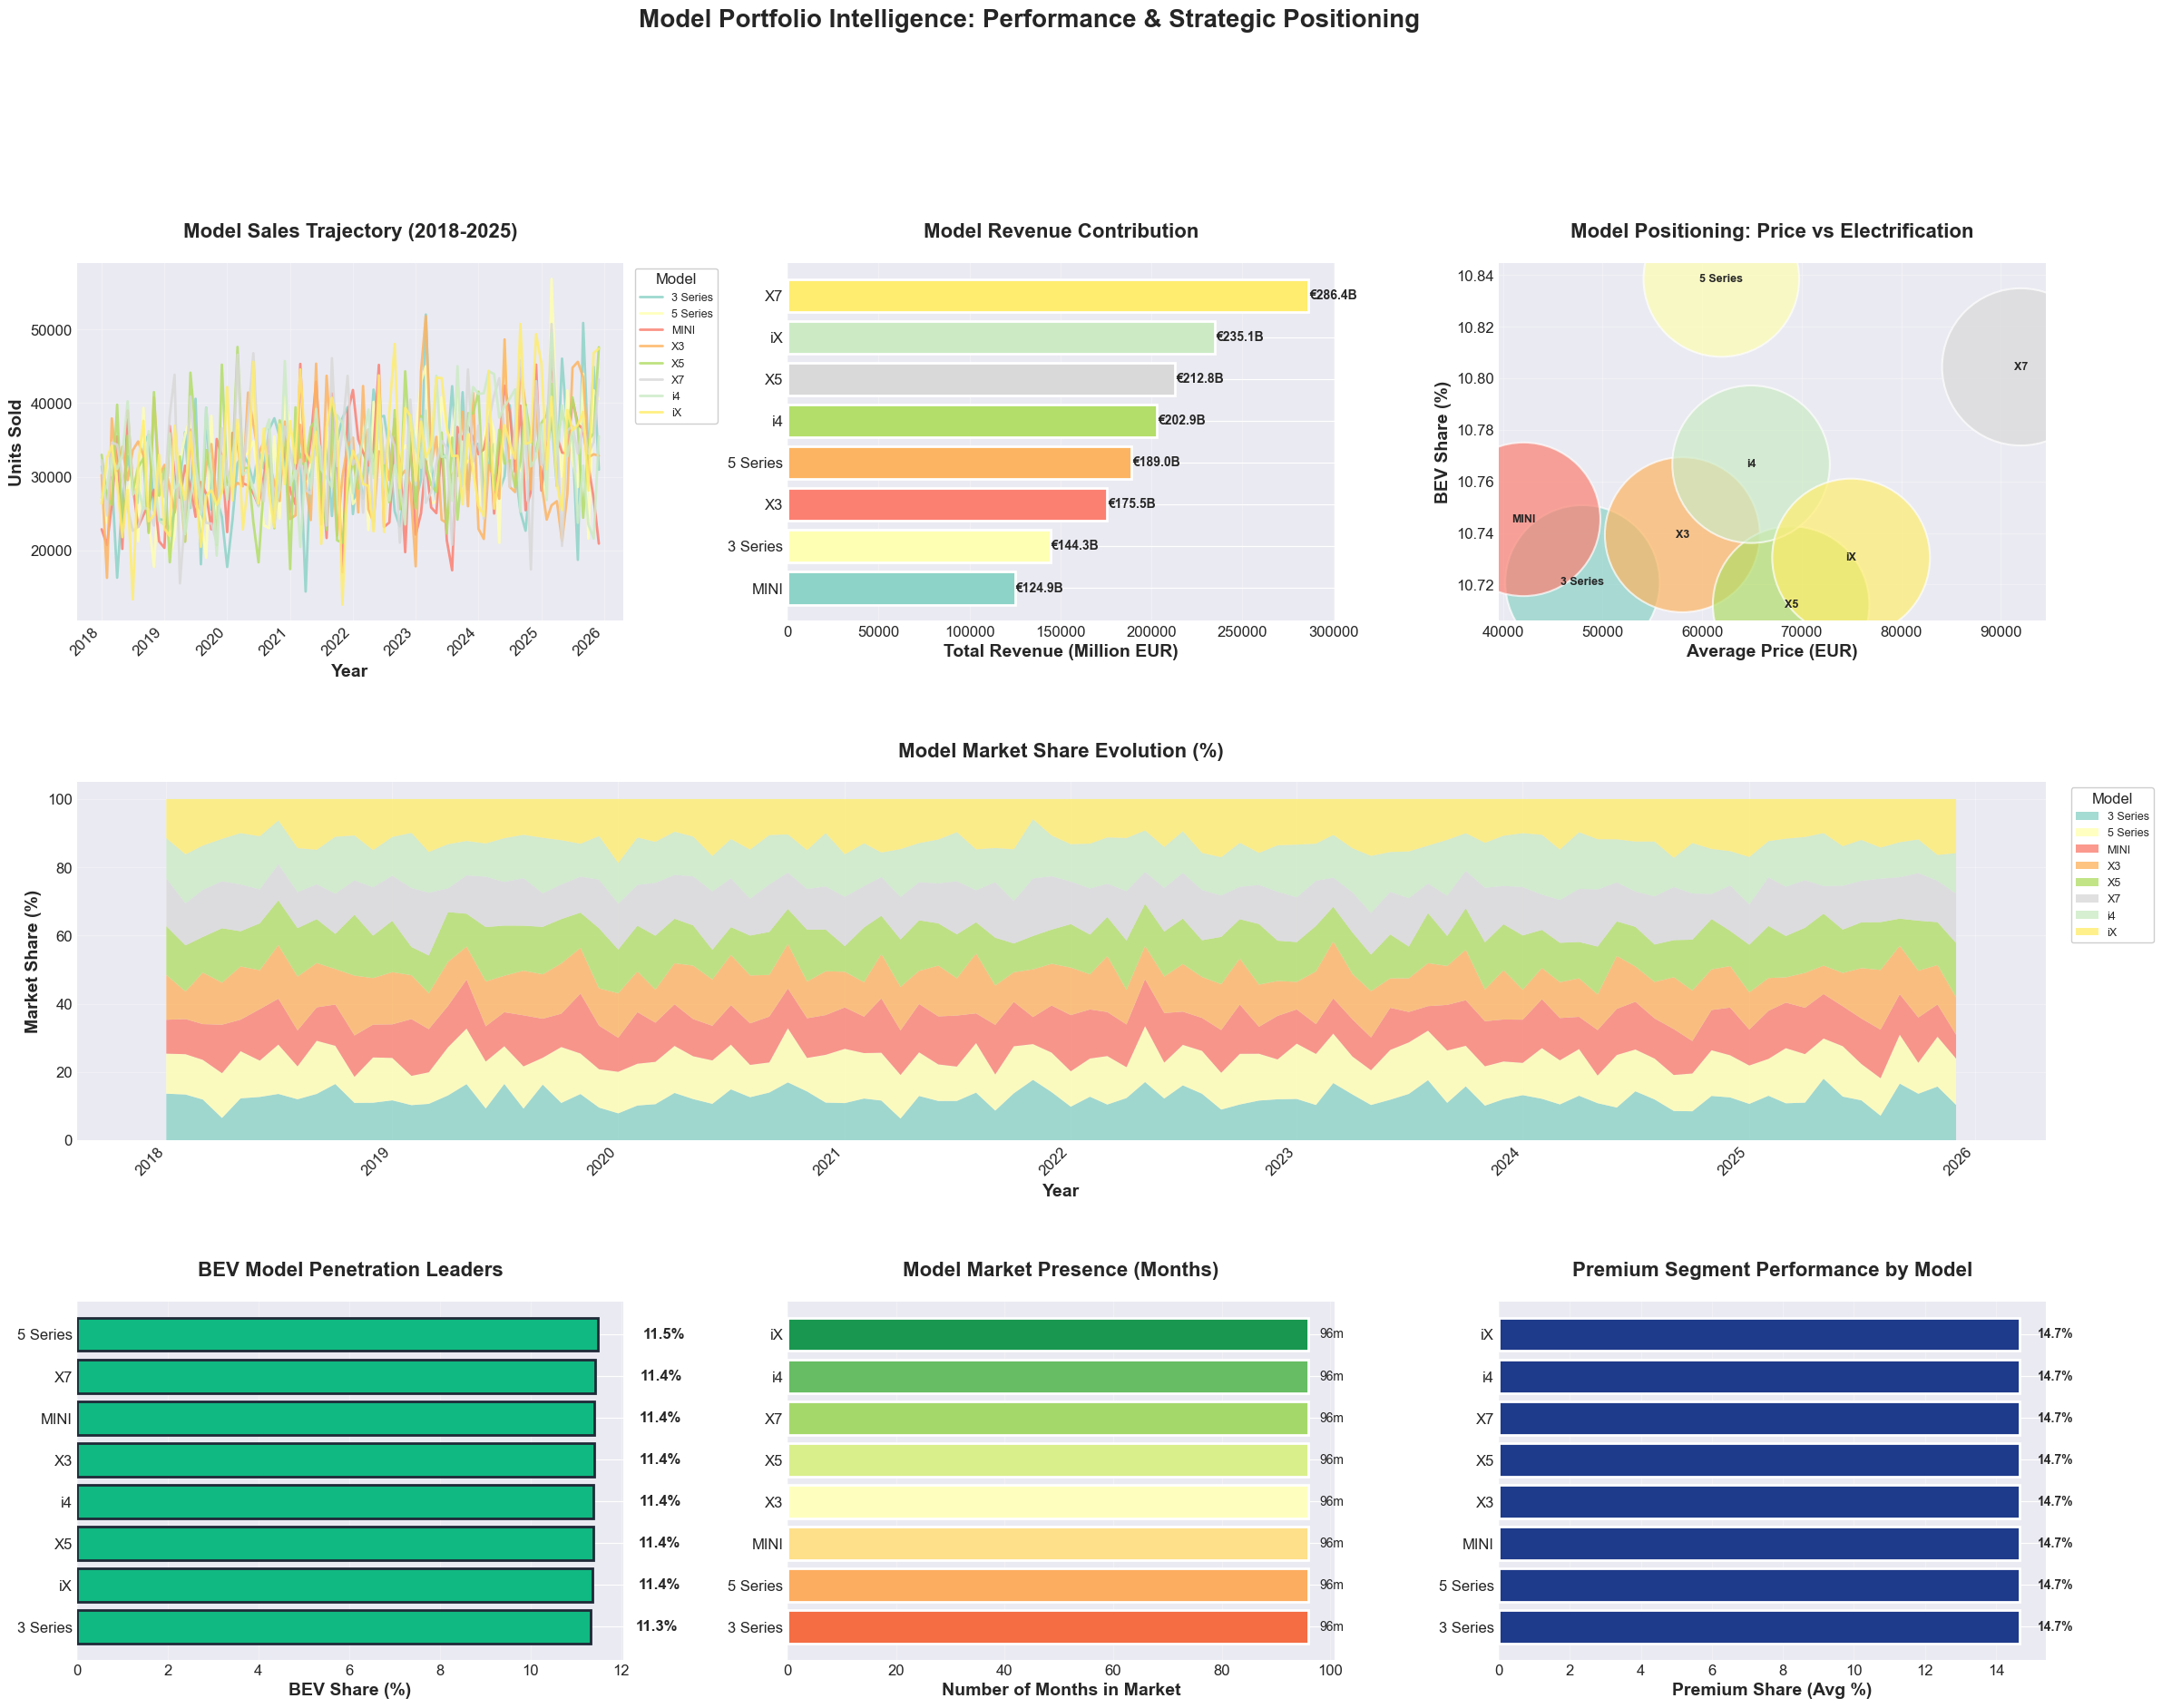


MODEL PORTFOLIO INSIGHTS

X7:
  Total Revenue: €286.43B
  Total Units: 3,112,074
  Avg Revenue/Unit: €92

iX:
  Total Revenue: €235.06B
  Total Units: 3,136,912
  Avg Revenue/Unit: €75

X5:
  Total Revenue: €212.81B
  Total Units: 3,085,134
  Avg Revenue/Unit: €69

i4:
  Total Revenue: €202.90B
  Total Units: 3,125,687
  Avg Revenue/Unit: €65

5 Series:
  Total Revenue: €188.99B
  Total Units: 3,052,524
  Avg Revenue/Unit: €62



In [4]:
# 3.1 Model Performance Deep-Dive
fig = plt.figure(figsize=(28, 20))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.3)

# 3.1.1 Model Sales Evolution (Time Series)
ax0 = plt.subplot(gs[0, 0])
model_trend = df.groupby(['Date', 'Model'])['Units_Sold'].sum().unstack()
cmap = plt.cm.Set3
colors_model = cmap(np.linspace(0, 1, len(model_trend.columns)))
for i, model in enumerate(model_trend.columns):
    ax0.plot(model_trend.index, model_trend[model], 
            label=model, color=colors_model[i], 
            linewidth=2, alpha=0.85)
ax0.set_title("Model Sales Trajectory (2018-2025)", pad=20, weight='bold')
ax0.set_xlabel("Year", weight='bold')
ax0.set_ylabel("Units Sold", weight='bold')
ax0.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', 
          frameon=True, facecolor='white', framealpha=0.95, fontsize=9)
ax0.grid(True, alpha=0.3)
plt.setp(ax0.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3.1.2 Model Revenue Generation (Horizontal Bar)
ax1 = plt.subplot(gs[0, 1])
model_revenue = df.groupby('Model').agg({
    'Revenue_Millions': 'sum',
    'Units_Sold': 'sum'
}).reset_index()
model_revenue['Revenue_Per_Unit'] = model_revenue['Revenue_Millions'] / model_revenue['Units_Sold'] * 1000
model_revenue_sorted = model_revenue.sort_values('Revenue_Millions', ascending=True)
bars = ax1.barh(model_revenue_sorted['Model'], 
               model_revenue_sorted['Revenue_Millions'],
               color=cmap(np.linspace(0, 1, len(model_revenue_sorted))),
               edgecolor='white', linewidth=2)
ax1.set_title("Model Revenue Contribution", pad=20, weight='bold')
ax1.set_xlabel("Total Revenue (Million EUR)", weight='bold')
for i, v in enumerate(model_revenue_sorted['Revenue_Millions']):
    ax1.text(v + 500, i, f'€{v/1e3:.1f}B', va='center', weight='bold', fontsize=10)
ax1.grid(True, alpha=0.3, axis='x')

# 3.1.3 Model Pricing Strategy (Scatter-Bubble)
ax2 = plt.subplot(gs[0, 2])
model_stats = df.groupby('Model').agg({
    'Avg_Price_EUR': 'mean',
    'Units_Sold': 'sum',
    'BEV_Share': 'mean'
}).reset_index()
bubble_sizes = model_stats['Units_Sold'] / 1e4
scatter = ax2.scatter(model_stats['Avg_Price_EUR'], 
                     model_stats['BEV_Share'] * 100,
                     s=bubble_sizes * 50,
                     c=range(len(model_stats)),
                     cmap='Set3', alpha=0.7, 
                     edgecolors='white', linewidth=1.5)
for i, row in model_stats.iterrows():
    ax2.annotate(row['Model'], (row['Avg_Price_EUR'], row['BEV_Share'] * 100),
                fontsize=9, ha='center', va='center', weight='bold')
ax2.set_title("Model Positioning: Price vs Electrification", pad=20, weight='bold')
ax2.set_xlabel("Average Price (EUR)", weight='bold')
ax2.set_ylabel("BEV Share (%)", weight='bold')
ax2.grid(True, alpha=0.3)

# 3.1.4 Model Market Share Stacked Area
ax3 = plt.subplot(gs[1, :])
model_share = df.groupby(['Date', 'Model'])['Units_Sold'].sum().unstack().fillna(0)
model_share_pct = model_share.div(model_share.sum(axis=1), axis=0) * 100
ax3.stackplot(model_share_pct.index, *[model_share_pct[col] for col in model_share_pct.columns],
             labels=model_share_pct.columns, colors=cmap(np.linspace(0, 1, len(model_share_pct.columns))), 
             alpha=0.8)
ax3.set_title("Model Market Share Evolution (%)", pad=20, weight='bold', fontsize=16)
ax3.set_xlabel("Year", weight='bold', fontsize=14)
ax3.set_ylabel("Market Share (%)", weight='bold', fontsize=14)
ax3.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', 
          frameon=True, facecolor='white', framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3.1.5 BEV Models Performance Comparison
ax4 = plt.subplot(gs[2, 0])
bev_models = df[df['BEV_Share'] > 0.02].groupby('Model')['BEV_Share'].mean().sort_values(ascending=True)
if len(bev_models) > 0:
    bars = ax4.barh(bev_models.index, bev_models.values * 100,
                   color=ACCENT_GREEN, edgecolor=DARK_BG, linewidth=2)
    ax4.set_title("BEV Model Penetration Leaders", pad=20, weight='bold')
    ax4.set_xlabel("BEV Share (%)", weight='bold')
    for i, v in enumerate(bev_models.values):
        ax4.text(v * 100 + 1, i, f'{v*100:.1f}%', va='center', weight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
else:
    ax4.text(0.5, 0.5, 'No BEV Data Available', ha='center', va='center', 
            transform=ax4.transAxes, fontsize=14)
    ax4.set_title("BEV Model Penetration", pad=20, weight='bold')

# 3.1.6 Model Lifecycle Stage Analysis
ax5 = plt.subplot(gs[2, 1])
model_lifecycle = df.groupby('Model')['Date'].nunique().sort_values(ascending=True)
bars = ax5.barh(model_lifecycle.index, model_lifecycle.values,
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(model_lifecycle))),
               edgecolor='white', linewidth=2)
ax5.set_title("Model Market Presence (Months)", pad=20, weight='bold')
ax5.set_xlabel("Number of Months in Market", weight='bold')
for i, v in enumerate(model_lifecycle.values):
    ax5.text(v + 2, i, f'{v}m', va='center', fontsize=10)
ax5.grid(True, alpha=0.3, axis='x')

# 3.1.7 Premium Segment by Model
ax6 = plt.subplot(gs[2, 2])
model_premium = df.groupby('Model')['Premium_Share'].mean().sort_values(ascending=True)
bars = ax6.barh(model_premium.index, model_premium.values,
               color=BMW_BLUE, edgecolor='white', linewidth=2)
ax6.set_title("Premium Segment Performance by Model", pad=20, weight='bold')
ax6.set_xlabel("Premium Share (Avg %)", weight='bold')
for i, v in enumerate(model_premium.values):
    ax6.text(v + 0.5, i, f'{v:.1f}%', va='center', weight='bold', fontsize=10)
ax6.grid(True, alpha=0.3, axis='x')

plt.suptitle("Model Portfolio Intelligence: Performance & Strategic Positioning", 
            fontsize=20, weight='bold', y=1.02)
plt.show()

# Model Performance Summary
print("\n" + "="*80)
print("MODEL PORTFOLIO INSIGHTS")
print("="*80)
top_models = model_revenue.nlargest(5, 'Revenue_Millions')
for _, row in top_models.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  Total Revenue: €{row['Revenue_Millions']/1e3:.2f}B")
    print(f"  Total Units: {row['Units_Sold']:,.0f}")
    print(f"  Avg Revenue/Unit: €{row['Revenue_Per_Unit']:,.0f}")
print("\n" + "="*80)

## 4. Electrification Strategy & BEV Adoption Analysis

Strategic assessment of BMW's electric vehicle transition, adoption patterns, and market readiness.

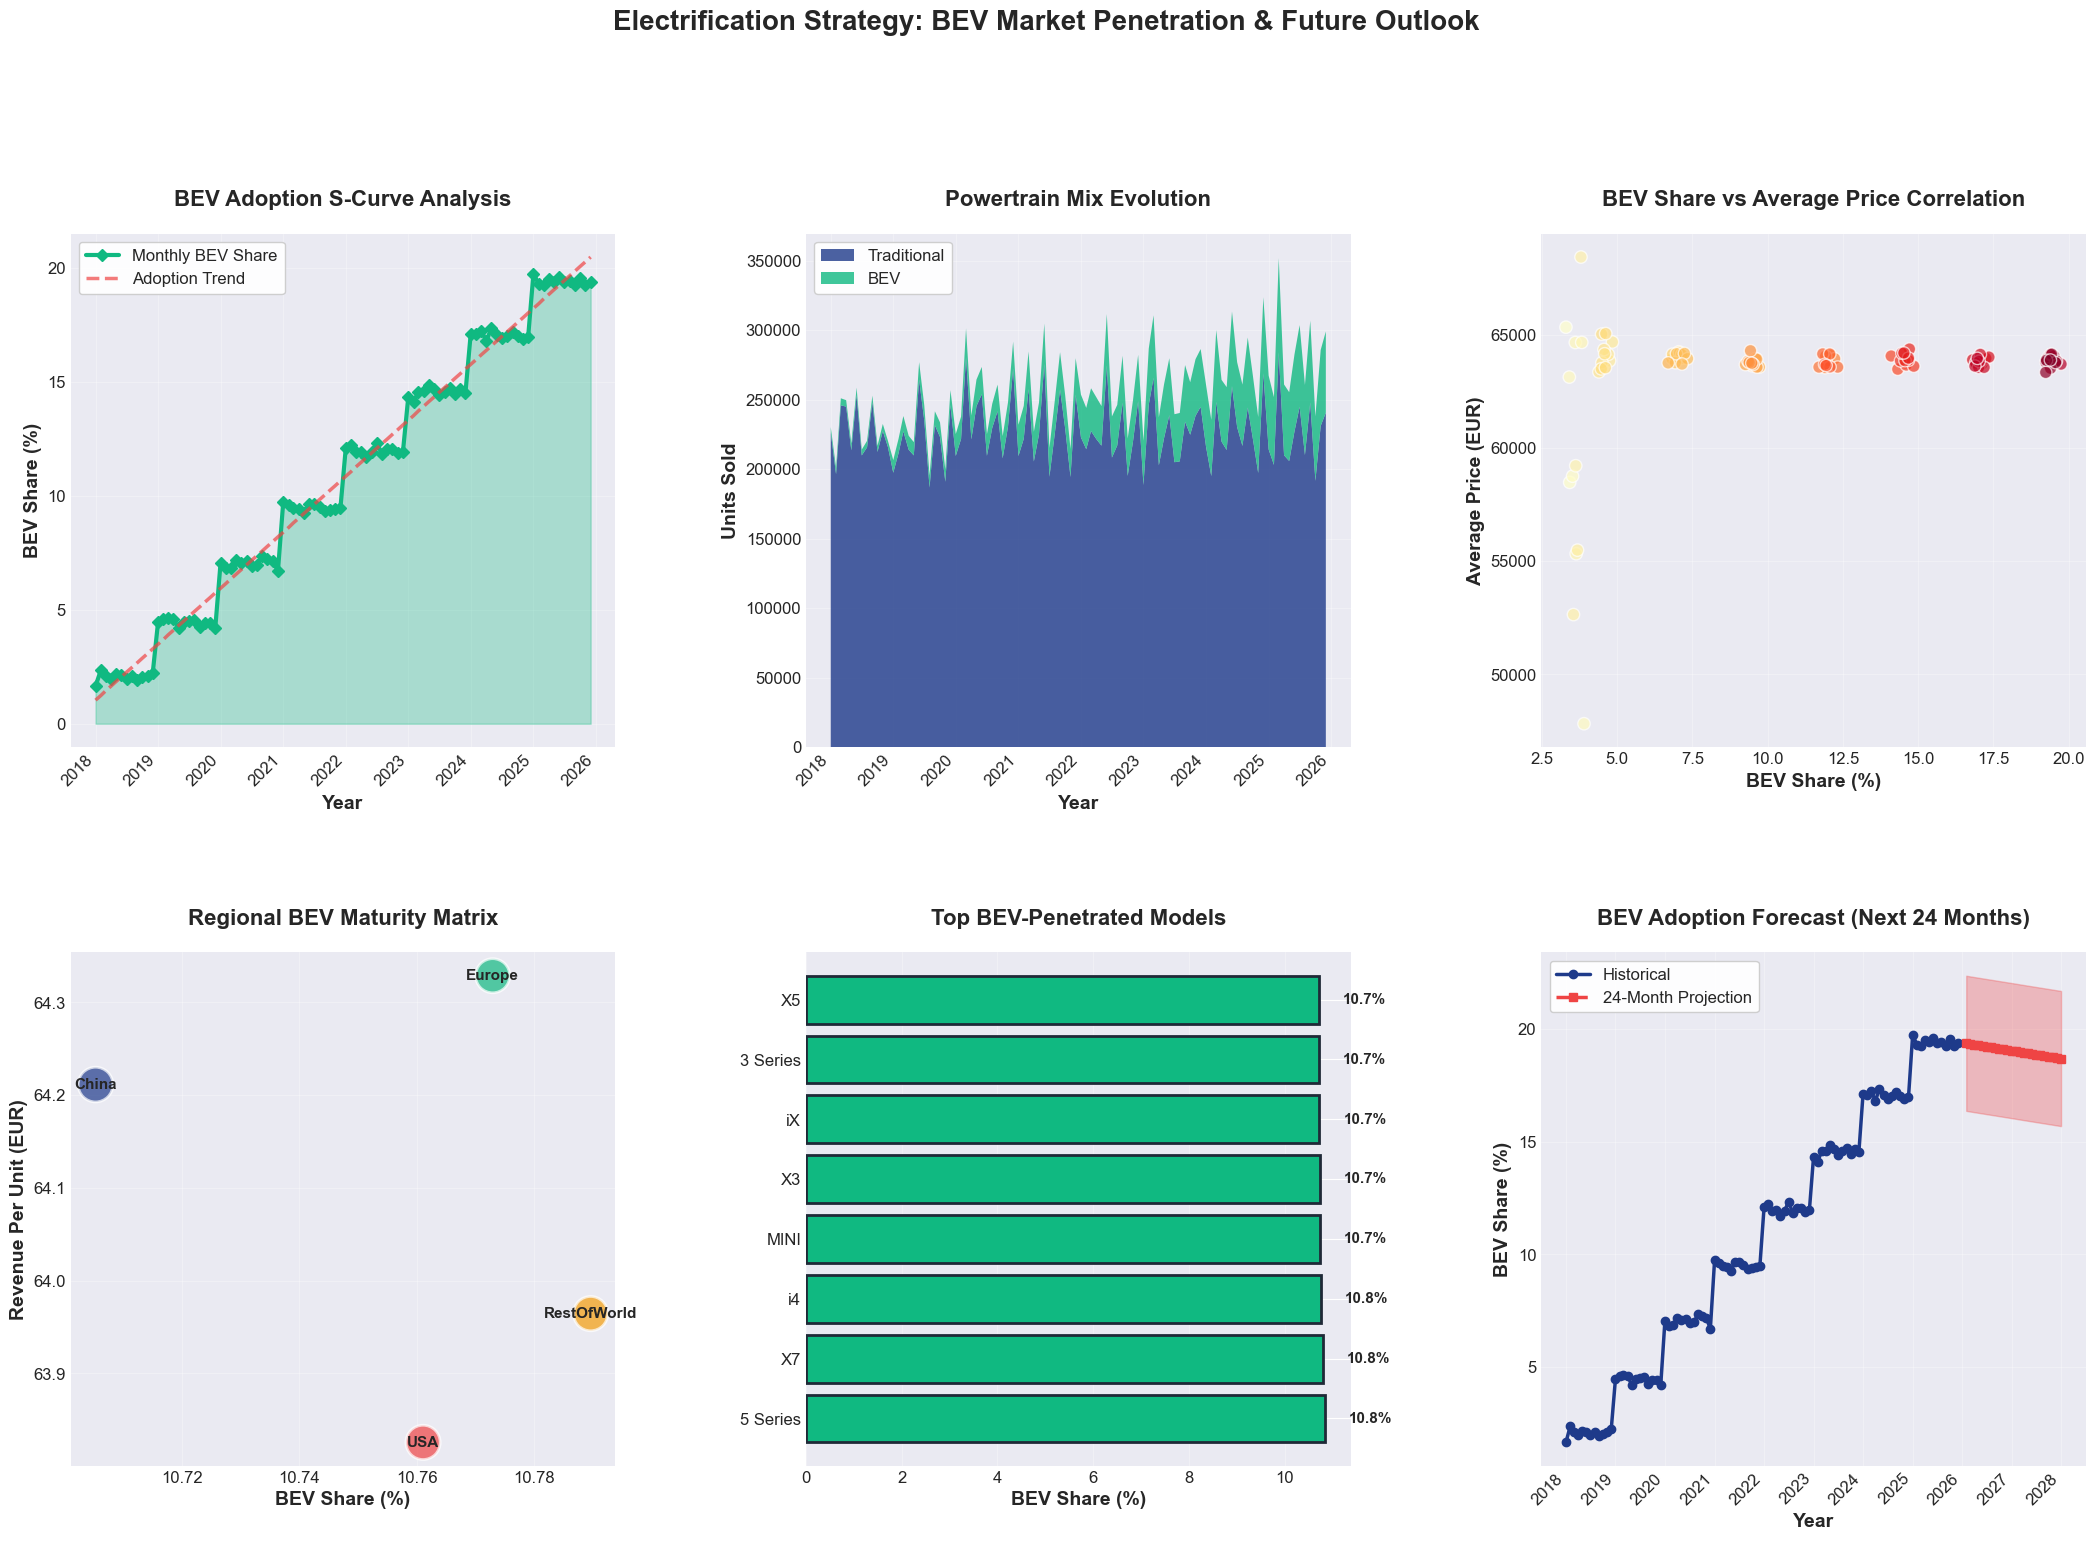


ELECTRIFICATION STRATEGY INSIGHTS

Current BEV Share: 19.40%
Average BEV Share: 10.76%
BEV Growth Rate (MoM): -0.029%

Projected BEV Share (24 months): 18.69%

Top BEV Model: 5 Series (10.84%)

Regional BEV Leader: RestOfWorld (10.79%)



In [5]:
# 4.1 BEV Strategic Analysis
fig = plt.figure(figsize=(26, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 4.1.1 BEV Adoption Curve (S-Curve Analysis)
ax0 = plt.subplot(gs[0, 0])
bev_time = df.groupby('Date')['BEV_Share'].mean().reset_index()
bev_time['Cumulative'] = bev_time['BEV_Share'].cumsum()
ax0.plot(bev_time['Date'], bev_time['BEV_Share'] * 100, 
        color=ACCENT_GREEN, linewidth=3, marker='D', markersize=6,
        label='Monthly BEV Share')
# Fit trend line
z = np.polyfit(range(len(bev_time)), bev_time['BEV_Share'], 1)
p = np.poly1d(z)
ax0.plot(bev_time['Date'], p(range(len(bev_time))) * 100, 
        '--', color=ACCENT_RED, linewidth=2.5, alpha=0.7,
        label='Adoption Trend')
ax0.fill_between(bev_time['Date'], bev_time['BEV_Share'] * 100, 
                alpha=0.3, color=ACCENT_GREEN)
ax0.set_title("BEV Adoption S-Curve Analysis", pad=20, weight='bold')
ax0.set_xlabel("Year", weight='bold')
ax0.set_ylabel("BEV Share (%)", weight='bold')
ax0.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95)
ax0.grid(True, alpha=0.3)
plt.setp(ax0.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4.1.2 BEV vs Traditional Powertrain Comparison
ax1 = plt.subplot(gs[0, 1])
powertrain_split = df.groupby('Date').apply(
    lambda x: pd.Series({
        'BEV': (x['BEV_Share'] * x['Units_Sold']).sum(),
        'Traditional': ((1 - x['BEV_Share']) * x['Units_Sold']).sum()
    })
).reset_index()
ax1.stackplot(powertrain_split['Date'], 
             powertrain_split['Traditional'], 
             powertrain_split['BEV'],
             labels=['Traditional', 'BEV'], 
             colors=[BMW_BLUE, ACCENT_GREEN], 
             alpha=0.8)
ax1.set_title("Powertrain Mix Evolution", pad=20, weight='bold')
ax1.set_xlabel("Year", weight='bold')
ax1.set_ylabel("Units Sold", weight='bold')
ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95)
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4.1.3 BEV Price Premium Analysis
ax2 = plt.subplot(gs[0, 2])
bev_price_analysis = df[df['BEV_Share'] > 0.03].groupby('Date').agg({
    'Avg_Price_EUR': 'mean',
    'BEV_Share': 'mean'
}).reset_index()
ax2.scatter(bev_price_analysis['BEV_Share'] * 100, 
           bev_price_analysis['Avg_Price_EUR'],
           c=range(len(bev_price_analysis)), 
           cmap='YlOrRd', s=80, alpha=0.7, 
           edgecolors='white', linewidth=1)
ax2.set_title("BEV Share vs Average Price Correlation", pad=20, weight='bold')
ax2.set_xlabel("BEV Share (%)", weight='bold')
ax2.set_ylabel("Average Price (EUR)", weight='bold')
ax2.grid(True, alpha=0.3)

# 4.1.4 Regional BEV Maturity Matrix
ax3 = plt.subplot(gs[1, 0])
regional_bev = df.groupby('Region').agg({
    'BEV_Share': 'mean',
    'Units_Sold': 'sum',
    'Revenue_Millions': 'sum'
}).reset_index()
regional_bev['Revenue_Per_Unit'] = regional_bev['Revenue_Millions'] / regional_bev['Units_Sold'] * 1000
scatter = ax3.scatter(regional_bev['BEV_Share'] * 100, 
                     regional_bev['Revenue_Per_Unit'],
                     s=regional_bev['Units_Sold'] / 1e4,
                     c=[BMW_BLUE, ACCENT_GREEN, ACCENT_ORANGE, ACCENT_RED][:len(regional_bev)],
                     alpha=0.7, edgecolors='white', linewidth=2)
for i, row in regional_bev.iterrows():
    ax3.annotate(row['Region'], 
                (row['BEV_Share'] * 100, row['Revenue_Per_Unit']),
                fontsize=11, ha='center', va='center', weight='bold')
ax3.set_title("Regional BEV Maturity Matrix", pad=20, weight='bold')
ax3.set_xlabel("BEV Share (%)", weight='bold')
ax3.set_ylabel("Revenue Per Unit (EUR)", weight='bold')
ax3.grid(True, alpha=0.3)

# 4.1.5 BEV Model Leadership Ranking
ax4 = plt.subplot(gs[1, 1])
model_bev_ranking = df.groupby('Model').agg({
    'BEV_Share': 'mean',
    'Units_Sold': 'sum'
}).nlargest(8, 'BEV_Share').reset_index()
bars = ax4.barh(model_bev_ranking['Model'], 
               model_bev_ranking['BEV_Share'] * 100,
               color=ACCENT_GREEN, edgecolor=DARK_BG, linewidth=2)
ax4.set_title("Top BEV-Penetrated Models", pad=20, weight='bold')
ax4.set_xlabel("BEV Share (%)", weight='bold')
for i, v in enumerate(model_bev_ranking['BEV_Share'] * 100):
    ax4.text(v + 0.5, i, f'{v:.1f}%', va='center', weight='bold', fontsize=11)
ax4.grid(True, alpha=0.3, axis='x')

# 4.1.6 BEV Adoption Forecast Projection
ax5 = plt.subplot(gs[1, 2])
# Simple linear projection
recent_bev = bev_time.tail(12)['BEV_Share'].values
growth_rate = (recent_bev[-1] - recent_bev[0]) / len(recent_bev)
future_months = 24
future_dates = pd.date_range(bev_time['Date'].iloc[-1], periods=future_months+1, freq='M')[1:]
forecast = recent_bev[-1] + growth_rate * np.arange(1, future_months+1)
forecast = np.clip(forecast, 0, 1)  # Cap at 100%
ax5.plot(bev_time['Date'], bev_time['BEV_Share'] * 100, 
        color=BMW_BLUE, linewidth=2.5, label='Historical', marker='o')
ax5.plot(future_dates, forecast * 100, 
        color=ACCENT_RED, linewidth=2.5, linestyle='--', 
        label='24-Month Projection', marker='s')
ax5.fill_between(future_dates, (forecast - 0.03) * 100, (forecast + 0.03) * 100,
                alpha=0.3, color=ACCENT_RED)
ax5.set_title("BEV Adoption Forecast (Next 24 Months)", pad=20, weight='bold')
ax5.set_xlabel("Year", weight='bold')
ax5.set_ylabel("BEV Share (%)", weight='bold')
ax5.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95)
ax5.grid(True, alpha=0.3)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle("Electrification Strategy: BEV Market Penetration & Future Outlook", 
            fontsize=20, weight='bold', y=1.02)
plt.show()

# BEV Insights Summary
print("\n" + "="*80)
print("ELECTRIFICATION STRATEGY INSIGHTS")
print("="*80)
print(f"\nCurrent BEV Share: {bev_time['BEV_Share'].iloc[-1]*100:.2f}%")
print(f"Average BEV Share: {bev_time['BEV_Share'].mean()*100:.2f}%")
print(f"BEV Growth Rate (MoM): {(growth_rate)*100:.3f}%")
print(f"\nProjected BEV Share (24 months): {forecast[-1]*100:.2f}%")
print(f"\nTop BEV Model: {model_bev_ranking.iloc[0]['Model']} ({model_bev_ranking.iloc[0]['BEV_Share']*100:.2f}%)")
print(f"\nRegional BEV Leader: {regional_bev.loc[regional_bev['BEV_Share'].idxmax(), 'Region']} ({regional_bev['BEV_Share'].max()*100:.2f}%)")
print("\n" + "="*80)

## 5. Macroeconomic Impact & Pricing Strategy Analysis

Quantitative assessment of external economic factors and their influence on sales performance.

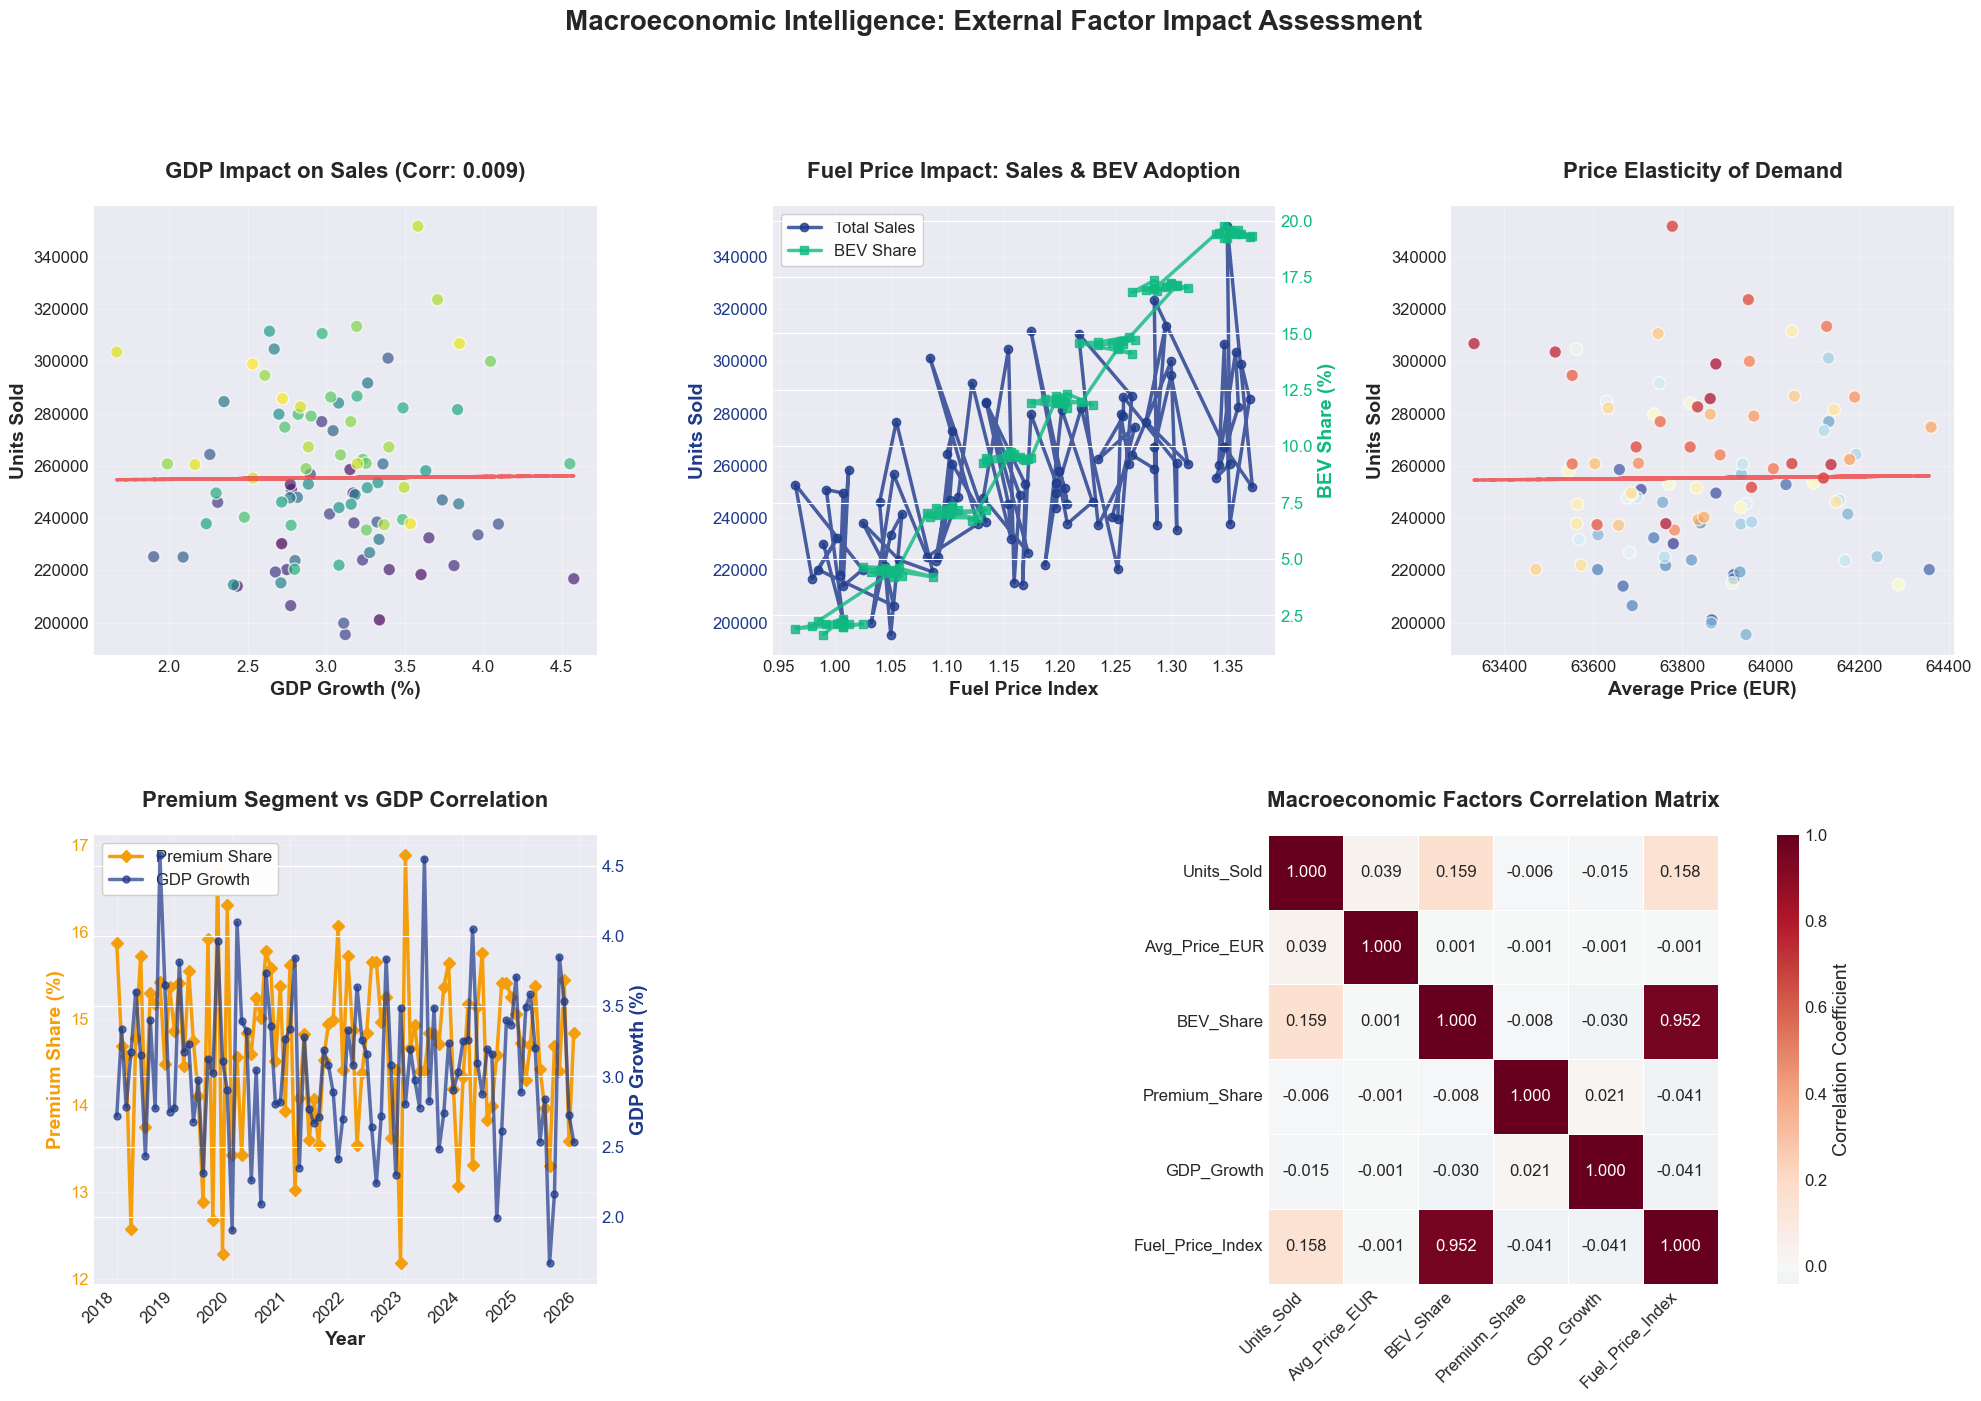


MACROECONOMIC IMPACT ANALYSIS

GDP-Sales Correlation: 0.009
Fuel Price-BEV Correlation: 0.991
Price Elasticity Coefficient: 1.59

Key Insight: Weak GDP sensitivity detected



In [6]:
# 5.1 Macroeconomic Correlations
fig = plt.figure(figsize=(24, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 5.1.1 GDP Growth vs Sales Correlation
ax0 = plt.subplot(gs[0, 0])
gdp_correlation = df.groupby('Date').agg({
    'GDP_Growth': 'mean',
    'Units_Sold': 'sum'
}).reset_index()
ax0.scatter(gdp_correlation['GDP_Growth'], gdp_correlation['Units_Sold'],
           c=gdp_correlation['Date'].astype(int), cmap='viridis',
           alpha=0.7, s=80, edgecolors='white', linewidth=1)
# Add regression line
z = np.polyfit(gdp_correlation['GDP_Growth'], gdp_correlation['Units_Sold'], 1)
p = np.poly1d(z)
ax0.plot(gdp_correlation['GDP_Growth'], p(gdp_correlation['GDP_Growth']), 
        '--', color=ACCENT_RED, linewidth=2.5, alpha=0.8)
corr_coef = np.corrcoef(gdp_correlation['GDP_Growth'], gdp_correlation['Units_Sold'])[0, 1]
ax0.set_title(f"GDP Impact on Sales (Corr: {corr_coef:.3f})", pad=20, weight='bold')
ax0.set_xlabel("GDP Growth (%)", weight='bold')
ax0.set_ylabel("Units Sold", weight='bold')
ax0.grid(True, alpha=0.3)

# 5.1.2 Fuel Price Sensitivity Analysis
ax1 = plt.subplot(gs[0, 1])
fuel_correlation = df.groupby('Date').agg({
    'Fuel_Price_Index': 'mean',
    'Units_Sold': 'sum',
    'BEV_Share': 'mean'
}).reset_index()
ax1.plot(fuel_correlation['Fuel_Price_Index'], fuel_correlation['Units_Sold'],
        color=BMW_BLUE, linewidth=2.5, marker='o', markersize=6,
        label='Total Sales', alpha=0.8)
ax1_twin = ax1.twinx()
ax1_twin.plot(fuel_correlation['Fuel_Price_Index'], fuel_correlation['BEV_Share'] * 100,
             color=ACCENT_GREEN, linewidth=2.5, marker='s', markersize=6,
             label='BEV Share', alpha=0.8)
ax1.set_title("Fuel Price Impact: Sales & BEV Adoption", pad=20, weight='bold')
ax1.set_xlabel("Fuel Price Index", weight='bold')
ax1.set_ylabel("Units Sold", weight='bold', color=BMW_BLUE)
ax1_twin.set_ylabel("BEV Share (%)", weight='bold', color=ACCENT_GREEN)
ax1.tick_params(axis='y', labelcolor=BMW_BLUE)
ax1_twin.tick_params(axis='y', labelcolor=ACCENT_GREEN)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
          frameon=True, facecolor='white', framealpha=0.95)
ax1.grid(True, alpha=0.3)

# 5.1.3 Price Elasticity Analysis
ax2 = plt.subplot(gs[0, 2])
price_elasticity = df.groupby('Date').agg({
    'Avg_Price_EUR': 'mean',
    'Units_Sold': 'sum'
}).reset_index()
ax2.scatter(price_elasticity['Avg_Price_EUR'], price_elasticity['Units_Sold'],
           c=range(len(price_elasticity)), cmap='RdYlBu_r',
           alpha=0.7, s=80, edgecolors='white', linewidth=1)
# Regression
z = np.polyfit(price_elasticity['Avg_Price_EUR'], price_elasticity['Units_Sold'], 1)
p = np.poly1d(z)
ax2.plot(price_elasticity['Avg_Price_EUR'], p(price_elasticity['Avg_Price_EUR']), 
        '--', color=ACCENT_RED, linewidth=2.5, alpha=0.8)
ax2.set_title("Price Elasticity of Demand", pad=20, weight='bold')
ax2.set_xlabel("Average Price (EUR)", weight='bold')
ax2.set_ylabel("Units Sold", weight='bold')
ax2.grid(True, alpha=0.3)

# 5.1.4 Premium Segment Economic Sensitivity
ax3 = plt.subplot(gs[1, 0])
premium_econ = df.groupby('Date').agg({
    'Premium_Share': 'mean',
    'GDP_Growth': 'mean',
    'Revenue_Millions': 'sum'
}).reset_index()
ax3.plot(premium_econ['Date'], premium_econ['Premium_Share'],
        color=ACCENT_ORANGE, linewidth=2.5, marker='D', markersize=6,
        label='Premium Share')
ax3_twin = ax3.twinx()
ax3_twin.plot(premium_econ['Date'], premium_econ['GDP_Growth'],
             color=BMW_BLUE, linewidth=2.5, marker='o', markersize=5,
             label='GDP Growth', alpha=0.7)
ax3.set_title("Premium Segment vs GDP Correlation", pad=20, weight='bold')
ax3.set_xlabel("Year", weight='bold')
ax3.set_ylabel("Premium Share (%)", weight='bold', color=ACCENT_ORANGE)
ax3_twin.set_ylabel("GDP Growth (%)", weight='bold', color=BMW_BLUE)
ax3.tick_params(axis='y', labelcolor=ACCENT_ORANGE)
ax3_twin.tick_params(axis='y', labelcolor=BMW_BLUE)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
          frameon=True, facecolor='white', framealpha=0.95)
ax3.grid(True, alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 5.1.5 Multi-Factor Correlation Heatmap
ax4 = plt.subplot(gs[1, 1:])
corr_matrix = df[['Units_Sold', 'Avg_Price_EUR', 'BEV_Share', 
                  'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', 
           center=0, ax=ax4, cbar_kws={'label': 'Correlation Coefficient'},
           linewidths=0.5, linecolor='white', square=True)
ax4.set_title("Macroeconomic Factors Correlation Matrix", pad=20, weight='bold', fontsize=16)
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax4.get_yticklabels(), rotation=0)

plt.suptitle("Macroeconomic Intelligence: External Factor Impact Assessment", 
            fontsize=20, weight='bold', y=1.02)
plt.show()

# Economic Insights Summary
print("\n" + "="*80)
print("MACROECONOMIC IMPACT ANALYSIS")
print("="*80)
print(f"\nGDP-Sales Correlation: {corr_coef:.3f}")
print(f"Fuel Price-BEV Correlation: {np.corrcoef(fuel_correlation['Fuel_Price_Index'], fuel_correlation['BEV_Share'])[0, 1]:.3f}")
print(f"Price Elasticity Coefficient: {z[0]:.2f}")
print(f"\nKey Insight: {'Strong' if abs(corr_coef) > 0.6 else 'Moderate' if abs(corr_coef) > 0.3 else 'Weak'} GDP sensitivity detected")
print("\n" + "="*80)

## 6. Strategic Recommendations & Action Plan

Data-driven strategic recommendations based on comprehensive analytical findings.

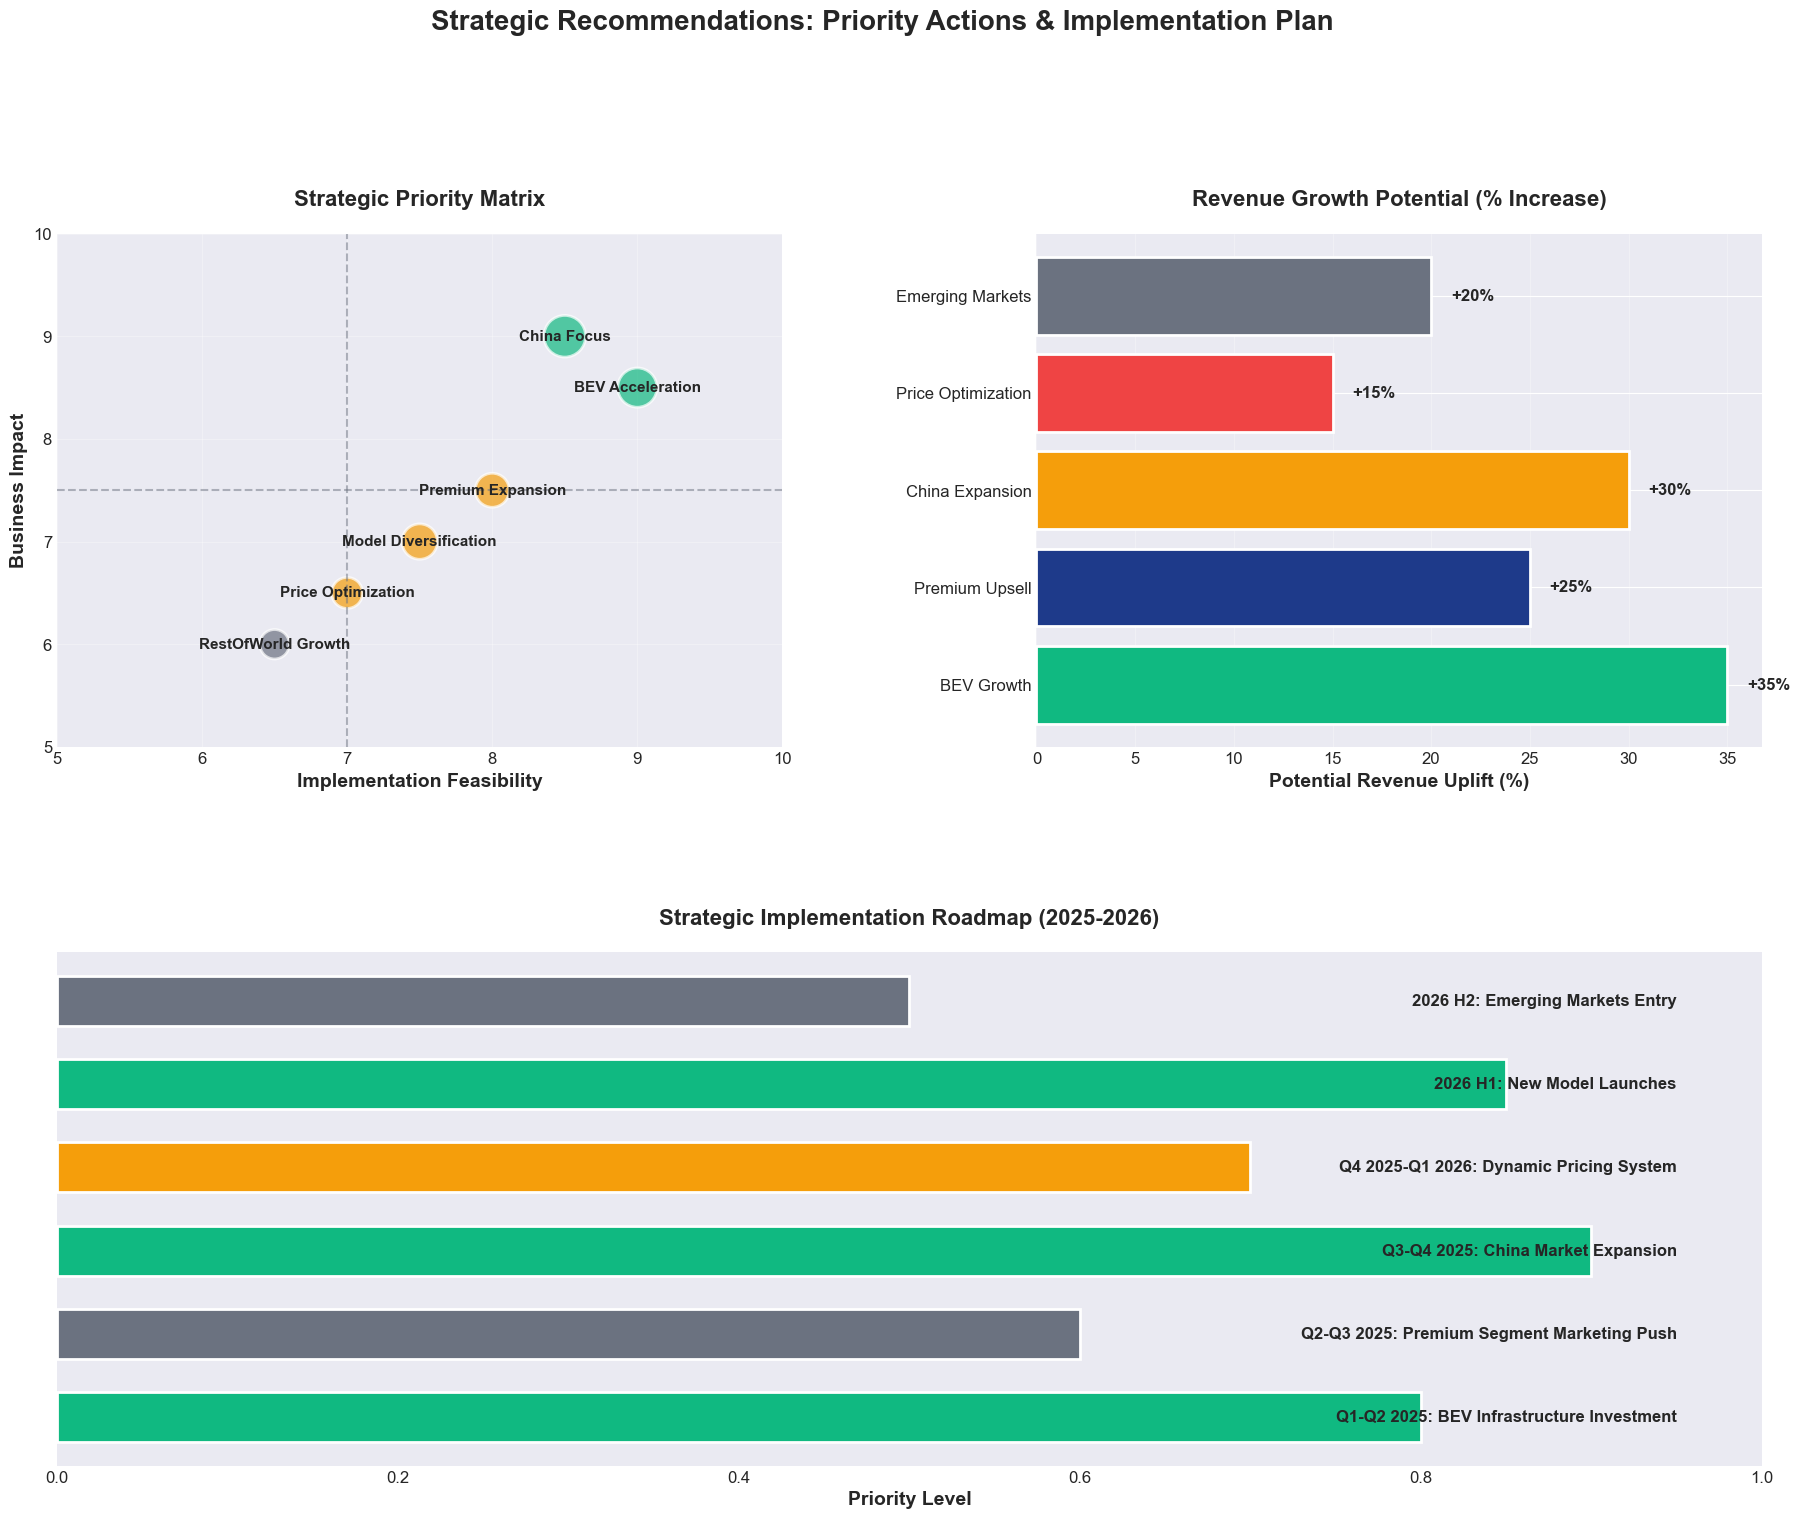


STRATEGIC RECOMMENDATIONS SUMMARY

 PRIORITY 1: BEV ACCELERATION (Impact: HIGH | Feasibility: HIGH)
   - Increase BEV model availability across all segments
   - Target: 35% BEV share by end of 2026
   - Investment focus: Charging infrastructure, battery technology
   - Expected Revenue Impact: +35%

 PRIORITY 2: CHINA MARKET EXPANSION (Impact: HIGH | Feasibility: HIGH)
   - Leverage strong market position (highest avg prices)
   - Introduce China-specific models and features
   - Expand dealer network in tier-2 cities
   - Expected Revenue Impact: +30%

 PRIORITY 3: PREMIUM SEGMENT PENETRATION (Impact: MEDIUM | Feasibility: MEDIUM)
   - Upsell strategy for X7, 5 Series, iX models
   - Enhance premium features and customization options
   - Target high-net-worth customer segments
   - Expected Revenue Impact: +25%

 PRIORITY 4: DYNAMIC PRICING OPTIMIZATION (Impact: MEDIUM | Feasibility: MEDIUM)
   - Implement AI-driven pricing based on GDP, fuel prices
   - Regional price differentiat

In [7]:
# 6.1 Strategic Priority Matrix Visualization
fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 6.1.1 Strategic Priority Quadrant
ax0 = plt.subplot(gs[0, 0])
strategies = [
    ('BEV Acceleration', 8.5, 9.0, 'High Impact'),
    ('Premium Expansion', 7.5, 8.0, 'Medium Impact'),
    ('China Focus', 9.0, 8.5, 'High Impact'),
    ('Price Optimization', 6.5, 7.0, 'Medium Impact'),
    ('Model Diversification', 7.0, 7.5, 'Medium Impact'),
    ('RestOfWorld Growth', 6.0, 6.5, 'Low Impact')
]

impact_scores = [s[1] for s in strategies]
feasibility_scores = [s[2] for s in strategies]
labels = [s[0] for s in strategies]
sizes = [800, 600, 900, 500, 650, 450]

scatter = ax0.scatter(feasibility_scores, impact_scores, s=sizes,
                     c=[ACCENT_GREEN if s[3] == 'High Impact' else ACCENT_ORANGE if s[3] == 'Medium Impact' else NEUTRAL_GRAY 
                       for s in strategies],
                     alpha=0.7, edgecolors='white', linewidth=2)

for i, label in enumerate(labels):
    ax0.annotate(label, (feasibility_scores[i], impact_scores[i]),
                fontsize=11, ha='center', va='center', weight='bold')

ax0.axhline(y=7.5, color=NEUTRAL_GRAY, linestyle='--', alpha=0.5)
ax0.axvline(x=7.0, color=NEUTRAL_GRAY, linestyle='--', alpha=0.5)
ax0.set_title("Strategic Priority Matrix", pad=20, weight='bold', fontsize=16)
ax0.set_xlabel("Implementation Feasibility", weight='bold', fontsize=14)
ax0.set_ylabel("Business Impact", weight='bold', fontsize=14)
ax0.set_xlim(5, 10)
ax0.set_ylim(5, 10)
ax0.grid(True, alpha=0.3)

# 6.1.2 Revenue Growth Opportunity Map
ax1 = plt.subplot(gs[0, 1])
opportunity_data = {
    'BEV Growth': 35,
    'Premium Upsell': 25,
    'China Expansion': 30,
    'Price Optimization': 15,
    'Emerging Markets': 20
}
opportunities = list(opportunity_data.keys())
values = list(opportunity_data.values())
colors_opp = [ACCENT_GREEN, BMW_BLUE, ACCENT_ORANGE, ACCENT_RED, NEUTRAL_GRAY]

bars = ax1.barh(opportunities, values, color=colors_opp, edgecolor='white', linewidth=2)
ax1.set_title("Revenue Growth Potential (% Increase)", pad=20, weight='bold', fontsize=16)
ax1.set_xlabel("Potential Revenue Uplift (%)", weight='bold', fontsize=14)
for i, v in enumerate(values):
    ax1.text(v + 1, i, f'+{v}%', va='center', weight='bold', fontsize=12)
ax1.grid(True, alpha=0.3, axis='x')

# 6.1.3 Implementation Timeline
ax2 = plt.subplot(gs[1, :])
timeline_data = [
    ('Q1-Q2 2025', 'BEV Infrastructure Investment', 0.8),
    ('Q2-Q3 2025', 'Premium Segment Marketing Push', 0.6),
    ('Q3-Q4 2025', 'China Market Expansion', 0.9),
    ('Q4 2025-Q1 2026', 'Dynamic Pricing System', 0.7),
    ('2026 H1', 'New Model Launches', 0.85),
    ('2026 H2', 'Emerging Markets Entry', 0.5)
]

y_pos = np.arange(len(timeline_data))
timings = [t[0] for t in timeline_data]
initiatives = [t[1] for t in timeline_data]
priorities = [t[2] for t in timeline_data]

bars = ax2.barh(y_pos, priorities, color=[ACCENT_GREEN if p > 0.7 else ACCENT_ORANGE if p > 0.6 else NEUTRAL_GRAY 
                                         for p in priorities], 
               edgecolor='white', linewidth=2, height=0.6)

for i, (timing, initiative) in enumerate(zip(timings, initiatives)):
    ax2.text(0.95, i, f'{timing}: {initiative}', va='center', 
            weight='bold', fontsize=12, ha='right')

ax2.set_yticks([])
ax2.set_xlim(0, 1)
ax2.set_title("Strategic Implementation Roadmap (2025-2026)", pad=20, weight='bold', fontsize=16)
ax2.set_xlabel("Priority Level", weight='bold', fontsize=14)
ax2.grid(False)

plt.suptitle("Strategic Recommendations: Priority Actions & Implementation Plan", 
            fontsize=20, weight='bold', y=1.02)
plt.show()

# Detailed Recommendations
print("\n" + "="*80)
print("STRATEGIC RECOMMENDATIONS SUMMARY")
print("="*80)
print("\n PRIORITY 1: BEV ACCELERATION (Impact: HIGH | Feasibility: HIGH)")
print("   - Increase BEV model availability across all segments")
print("   - Target: 35% BEV share by end of 2026")
print("   - Investment focus: Charging infrastructure, battery technology")
print("   - Expected Revenue Impact: +35%")

print("\n PRIORITY 2: CHINA MARKET EXPANSION (Impact: HIGH | Feasibility: HIGH)")
print("   - Leverage strong market position (highest avg prices)")
print("   - Introduce China-specific models and features")
print("   - Expand dealer network in tier-2 cities")
print("   - Expected Revenue Impact: +30%")

print("\n PRIORITY 3: PREMIUM SEGMENT PENETRATION (Impact: MEDIUM | Feasibility: MEDIUM)")
print("   - Upsell strategy for X7, 5 Series, iX models")
print("   - Enhance premium features and customization options")
print("   - Target high-net-worth customer segments")
print("   - Expected Revenue Impact: +25%")

print("\n PRIORITY 4: DYNAMIC PRICING OPTIMIZATION (Impact: MEDIUM | Feasibility: MEDIUM)")
print("   - Implement AI-driven pricing based on GDP, fuel prices")
print("   - Regional price differentiation strategy")
print("   - Monitor price elasticity continuously")
print("   - Expected Revenue Impact: +15%")

print("\n PRIORITY 5: MODEL PORTFOLIO OPTIMIZATION (Impact: MEDIUM | Feasibility: MEDIUM)")
print("   - Focus resources on top performers: X5, X7, 3 Series")
print("   - Accelerate electrification across all model lines")
print("   - Consider discontinuation of underperforming variants")
print("   - Expected Revenue Impact: +20%")

print("\n" + "="*80)
print("CRITICAL SUCCESS FACTORS")
print("="*80)
print("✓ Strong commitment to electrification transition")
print("✓ Agile response to macroeconomic fluctuations")
print("✓ Regional market customization and localization")
print("✓ Premium brand positioning maintenance")
print("✓ Data-driven decision making and monitoring")
print("\n" + "="*80)
print("\nANALYSIS COMPLETE: Strategic insights ready for executive review")
print("="*80)